#### Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torch.optim as optim

import torchvision
import torchvision.datasets as datasets
import torchvision.models as models

import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms


#### Setting up Training and Test Data for CIFAR-10

In [2]:
transform_cifar = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

root = "./data"

train_dataset_cifar = datasets.CIFAR10(root=root, train=True, transform=transform_cifar, download=True)
test_dataset_cifar = datasets.CIFAR10(root=root, train=False, transform=transform_cifar, download=True)

train_loader_cifar = DataLoader(train_dataset_cifar, batch_size=16, shuffle=True)
val_loader_cifar = DataLoader(test_dataset_cifar, batch_size=64, shuffle=False)


100%|██████████| 170M/170M [31:28<00:00, 90.3kB/s]


#### Loading Pretrained Resnet-152 Model


In [3]:
model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)

model.eval()


Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 186MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [5]:
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)
initial_fc_state = {k: v.detach().clone() for k, v in model.fc.state_dict().items()}


In [6]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)


Epoch 1 | Train Loss: 0.2250 | Train Acc: 0.9342 | Val Loss: 0.1645 | Val Acc: 0.9478
Epoch 2 | Train Loss: 0.1285 | Train Acc: 0.9573 | Val Loss: 0.1659 | Val Acc: 0.9497
Epoch 3 | Train Loss: 0.1056 | Train Acc: 0.9646 | Val Loss: 0.1614 | Val Acc: 0.9489


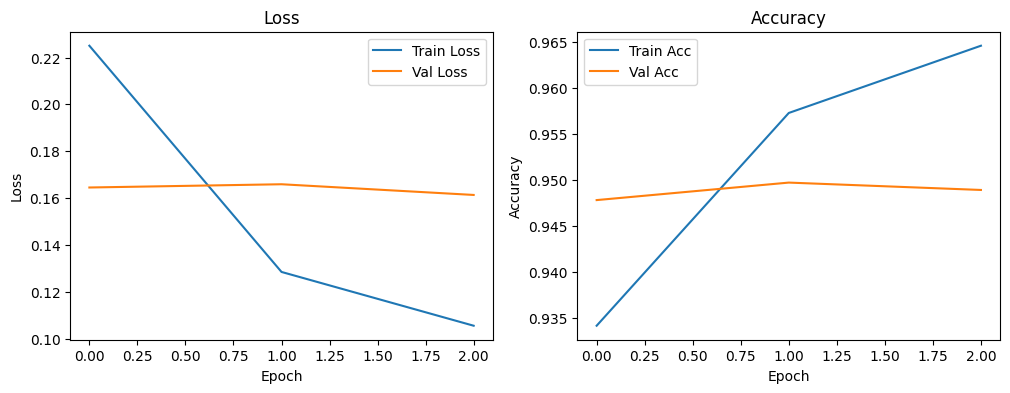

In [ ]:
def run_epoch(model, loader, criterion, optimizer, device, train=True):
    if train:
        model.eval()
        model.fc.train()
    else:
        model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(x)
            loss = criterion(logits, y)

            if train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * x.size(0)

        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy


history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

epochs = 3

for epoch in range(1, epochs + 1):
    train_loss, train_acc = run_epoch(
        model, train_loader_cifar, criterion, optimizer, device, train=True
    )

    val_loss, val_acc = run_epoch(
        model, val_loader_cifar, criterion, optimizer, device, train=False
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train Acc")
axes[1].plot(history["val_acc"], label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.show()


#### Exploring Training Without Residual Connections

Epoch 1 | Train Loss: 1.6312 | Train Acc: 0.4444 | Val Loss: 1.4647 | Val Acc: 0.4971
Epoch 2 | Train Loss: 1.3895 | Train Acc: 0.5271 | Val Loss: 1.3588 | Val Acc: 0.5353
Epoch 3 | Train Loss: 1.3103 | Train Acc: 0.5504 | Val Loss: 1.3006 | Val Acc: 0.5512


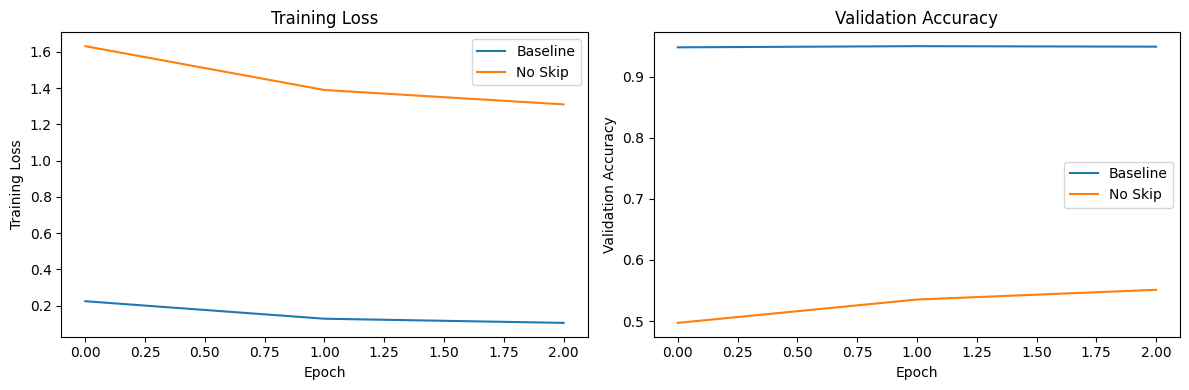

In [ ]:
import types
import copy

no_skip_model = copy.deepcopy(model)
no_skip_model.fc.load_state_dict(initial_fc_state)

def forward_no_skip(self, x):
    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)

    out = self.conv3(out)
    out = self.bn3(out)

    return self.relu(out)

no_skip_model.layer2[0].forward = types.MethodType(
    forward_no_skip, no_skip_model.layer2[0]
)
no_skip_model.layer3[0].forward = types.MethodType(
    forward_no_skip, no_skip_model.layer3[0]
)

for param in no_skip_model.parameters():
    param.requires_grad = False

for param in no_skip_model.fc.parameters():
    param.requires_grad = True

optimizer = optim.Adam(no_skip_model.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

no_skip_model.to(device)

history_no_skip = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": []
}

epochs = 3

for epoch in range(1, epochs + 1):
    train_loss, train_acc = run_epoch(
        no_skip_model, train_loader_cifar, criterion, optimizer, device, train=True
    )
    val_loss, val_acc = run_epoch(
        no_skip_model, val_loader_cifar, criterion, optimizer, device, train=False
    )

    history_no_skip["train_loss"].append(train_loss)
    history_no_skip["train_acc"].append(train_acc)
    history_no_skip["val_loss"].append(val_loss)
    history_no_skip["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Baseline")
axes[0].plot(history_no_skip["train_loss"], label="No Skip")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("Training Loss")
axes[0].legend()

axes[1].plot(history["val_acc"], label="Baseline")
axes[1].plot(history_no_skip["val_acc"], label="No Skip")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

del no_skip_model, optimizer
if torch.cuda.is_available():
    torch.cuda.empty_cache()


#### Feature Hierarchies and Representations

Samples: 640


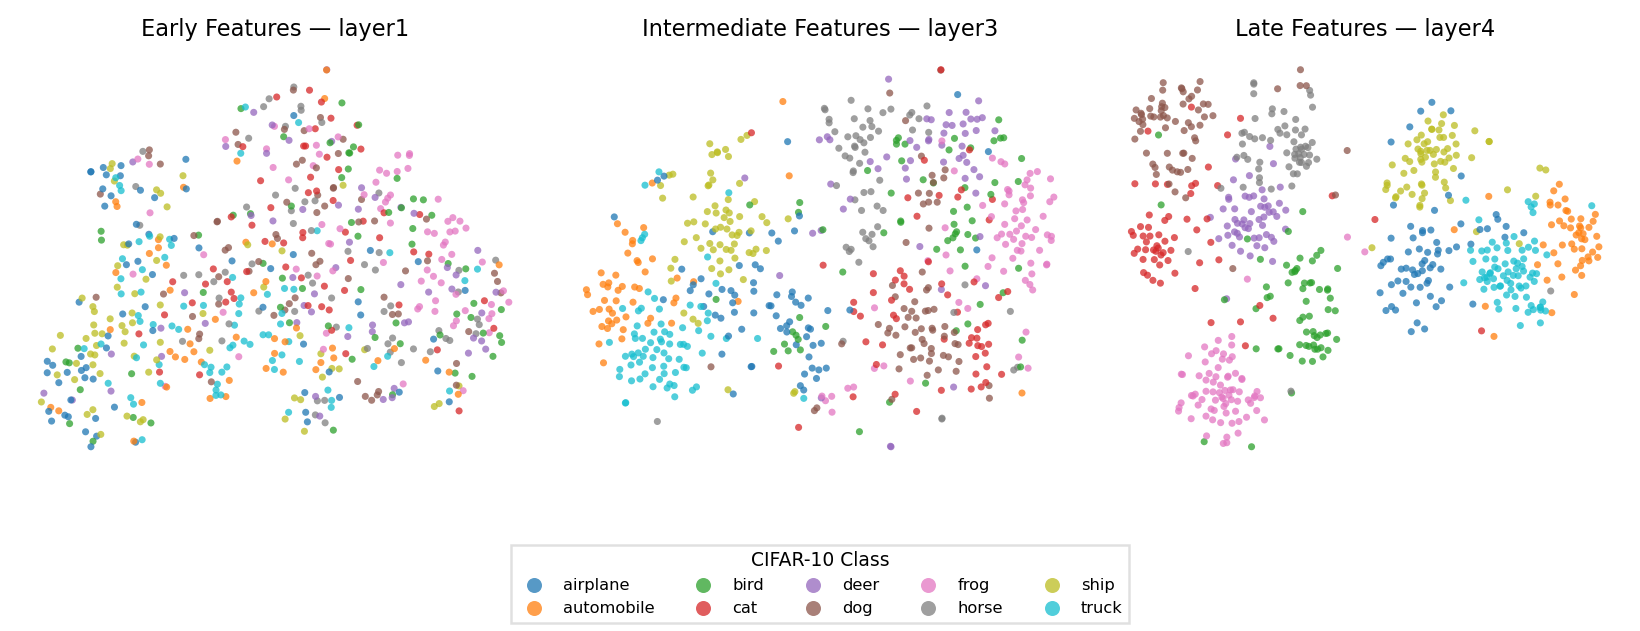

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

model = model.to(device)
model.eval()

for layer in [model.layer1, model.layer3, model.layer4]:
    layer._forward_hooks.clear()

features_layer1, features_layer3, features_layer4 = [], [], []

def get_hook(name):
    def hook(module, inputs, output):
        feat = output.detach().mean(dim=(2, 3)).cpu()

        if name == "layer1":
            features_layer1.append(feat)
        elif name == "layer3":
            features_layer3.append(feat)
        elif name == "layer4":
            features_layer4.append(feat)

    return hook

handles = [
    model.layer1.register_forward_hook(get_hook("layer1")),
    model.layer3.register_forward_hook(get_hook("layer3")),
    model.layer4.register_forward_hook(get_hook("layer4")),
]

subset_loader = DataLoader(
    test_dataset_cifar,
    batch_size=64,
    shuffle=False
)

labels_list = []

try:
    with torch.no_grad():
        for i, (x, y) in enumerate(subset_loader):
            if i >= 10:
                break

            model(x.to(device))
            labels_list.append(y.cpu())

finally:
    for h in handles:
        h.remove()

labels = torch.cat(labels_list).numpy()

layer1_np = torch.cat(features_layer1).numpy()
layer3_np = torch.cat(features_layer3).numpy()
layer4_np = torch.cat(features_layer4).numpy()

# Sanity check
assert (
    len(labels)
    == len(layer1_np)
    == len(layer3_np)
    == len(layer4_np)
)

print("Samples:", len(labels))

def run_tsne(features):
    return TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        random_state=42
    ).fit_transform(features)

layer1_2d = run_tsne(layer1_np)
layer3_2d = run_tsne(layer3_np)
layer4_2d = run_tsne(layer4_np)

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6), dpi=180)

titles = [
    "Early Features — layer1",
    "Intermediate Features — layer3",
    "Late Features — layer4",
]

for ax, data, title in zip(
    axes,
    [layer1_2d, layer3_2d, layer4_2d],
    titles
):
    scatter = ax.scatter(
        data[:, 0],
        data[:, 1],
        c=labels,
        cmap="tab10",
        s=8,
        alpha=0.75,
        linewidths=0
    )

    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

legend_handles, _ = scatter.legend_elements()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

fig.legend(
    legend_handles,
    class_names,
    title="CIFAR-10 Class",
    loc="lower center",
    ncol=5,
    frameon=True,
    fancybox=False,
    edgecolor="0.85",
    facecolor="white",
    fontsize=6.5,
    title_fontsize=7.5
)

plt.subplots_adjust(bottom=0.24, wspace=0.06)
plt.show()

model = model.cpu()
torch.cuda.empty_cache()

#### Transfer Learning

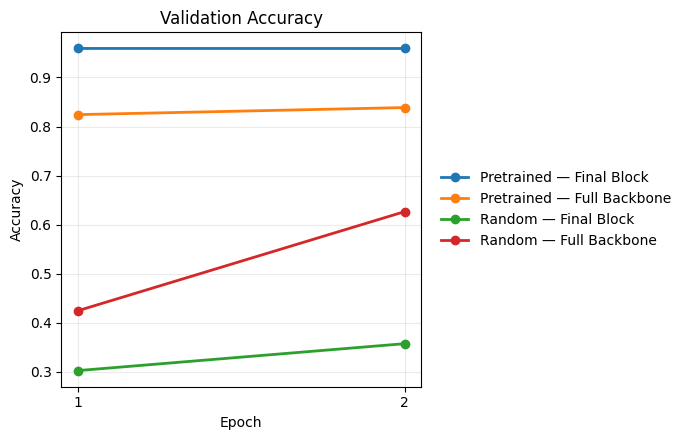

In [13]:
labels = {
    "pretrained_final_block": "Pretrained — Final Block",
    "pretrained_full_backbone": "Pretrained — Full Backbone",
    "random_final_block": "Random — Final Block",
    "random_full_backbone": "Random — Full Backbone",
}

epochs = range(1, len(next(iter(results.values()))["val_acc"]) + 1)

plt.figure(figsize=(7, 4.5))

for name, history in results.items():
    plt.plot(
        epochs,
        history["val_acc"],
        marker="o",
        linewidth=2,
        label=labels[name]
    )

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.grid(alpha=0.25)
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
plt.tight_layout()
plt.show()

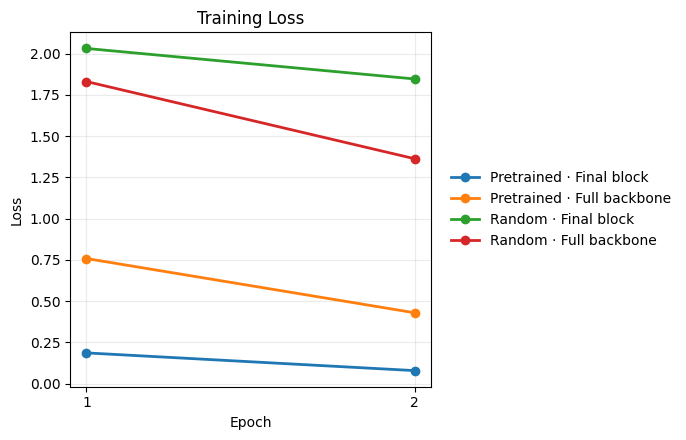

In [18]:
plt.figure(figsize=(7, 4.5))

for name, history in results.items():
    plt.plot(
        epochs,
        history["train_loss"],
        marker="o",
        linewidth=2,
        label=labels[name]
    )

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(alpha=0.25)
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
plt.tight_layout()
plt.show()

#### Optional Experiments

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


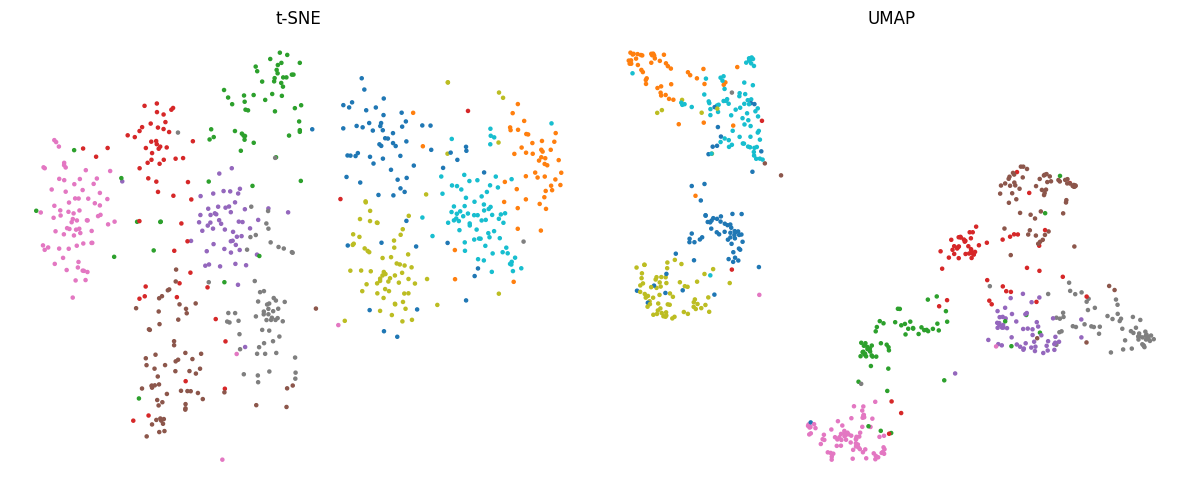

Confused cat -> dog: n=4, cosine sim=0.808
Confused horse -> deer: n=3, cosine sim=0.757
Confused airplane -> ship: n=3, cosine sim=0.793
Confused truck -> automobile: n=3, cosine sim=0.826
Confused dog -> cat: n=2, cosine sim=0.808
Centroid acc ResNet-152: 0.925
Centroid acc ResNet-18 : 0.823


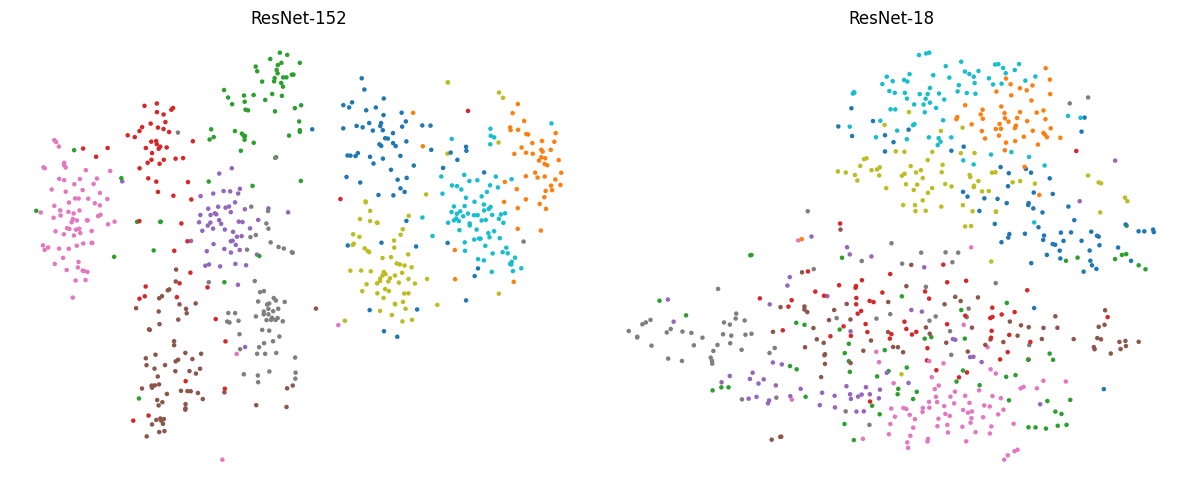

In [22]:
# !pip install -q umap-learn
import umap
import numpy as np
import torchvision.models as models
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

def extract(model, loader, n_batches=10):
    captured, preds, labs = [], [], []
    handle = model.avgpool.register_forward_hook(lambda m, i, o: captured.append(o.flatten(1).cpu()))
    model.eval()
    with torch.no_grad():
        for k, (x, y) in enumerate(loader):
            if k >= n_batches: break
            preds.append(model(x.to(device)).argmax(1).cpu())
            labs.append(y)
    handle.remove()
    return torch.cat(captured).numpy(), torch.cat(labs).numpy(), torch.cat(preds).numpy()

def centroid_acc(F, y):
    means = np.vstack([F[y == c].mean(0) for c in range(10)])
    return (euclidean_distances(F, means).argmin(1) == y).mean()

# Features from your fine-tuned ResNet-152 (global `model`)
model.to(device)
F152, y, yhat = extract(model, val_loader_cifar)

# (a) t-SNE vs UMAP
tsne_emb = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(F152)
umap_emb = umap.UMAP(n_components=2, random_state=0).fit_transform(F152)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, e, t in zip(ax, [tsne_emb, umap_emb], ["t-SNE", "UMAP"]):
    a.scatter(e[:, 0], e[:, 1], c=y, cmap="tab10", s=5)
    a.set_title(t)
    a.axis("off")
plt.tight_layout()
plt.show()

# (b) Most-confused classes and their feature similarity
cm = confusion_matrix(y, yhat)
np.fill_diagonal(cm, 0)
i1, i2 = np.unravel_index(np.argsort(cm, axis=None)[::-1][:5], cm.shape)
means = np.vstack([F152[y == c].mean(0) for c in range(10)])
cos = cosine_similarity(means)
for t, p in zip(i1, i2):
    print(f"Confused {classes[t]} -> {classes[p]}: n={cm[t, p]}, cosine sim={cos[t, p]:.3f}")

# (c) ResNet-152 vs ResNet-18 feature quality
model18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
F18, _, _ = extract(model18, val_loader_cifar)

print("Centroid acc ResNet-152:", round(centroid_acc(F152, y), 3))
print("Centroid acc ResNet-18 :", round(centroid_acc(F18, y), 3))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, F, t in zip(ax, [F152, F18], ["ResNet-152", "ResNet-18"]):
    e = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(F)
    a.scatter(e[:, 0], e[:, 1], c=y, cmap="tab10", s=5)
    a.set_title(t)
    a.axis("off")
plt.tight_layout()
plt.show()